# Cybersecurity Risk Analysis — Preliminary Analysis
**Course:** Machine Learning Project  
**Topic:** Cybersecurity Events Risk Classification  
**Dataset:** `cyber_events_2026-04-02.csv` — 16,328 Real-World Cyber Incidents  

---

## Notebook Structure

| Section | Description |
|---------|-------------|
| **1. Data Loading** | Import libraries, load dataset, initial inspection |
| **2. Data Cleaning & Preprocessing** | Handle missing values, fix data types, standardise categories |
| **3. Exploratory Data Analysis (EDA)** | Descriptive statistics, distribution summaries |
| **4. Visualisations** | Charts and plots for all key variables |

---
## Section 1 — Data Loading

In [ ]:
# ============================================================
# SECTION 1 — DATA LOADING
# ============================================================
# This section imports all required libraries and loads the
# cybersecurity events dataset into a Pandas DataFrame.
# ============================================================

# --- Standard Libraries ---
import pandas as pd          # Data manipulation and analysis
import numpy as np           # Numerical operations
import warnings
warnings.filterwarnings('ignore')

# --- Visualisation Libraries ---
import matplotlib.pyplot as plt   # Core plotting
import matplotlib.ticker as mtick # Axis formatting
import seaborn as sns             # Statistical visualisations

# --- Global Plot Settings ---
plt.rcParams['figure.figsize']    = (12, 5)      # Default figure size
plt.rcParams['font.family']       = 'sans-serif' # Clean font
plt.rcParams['axes.spines.top']   = False        # Remove top border
plt.rcParams['axes.spines.right'] = False        # Remove right border
plt.rcParams['axes.titlesize']    = 14           # Title font size
plt.rcParams['axes.labelsize']    = 12           # Axis label size

# --- Colour Palette (used consistently across all plots) ---
C_DARK   = '#1F3864'   # Dark navy blue  — primary bars / headings
C_MID    = '#2E5496'   # Mid blue        — secondary elements
C_LIGHT  = '#9DC3E6'   # Light blue      — tertiary / background
C_ACCENT = '#C00000'   # Red             — highlight / alerts

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [ ]:
# --- Load Dataset ---
# Place the CSV file in the same directory as this notebook.
# If stored elsewhere, update the file path below.

FILE_PATH = 'cyber_events_2026-04-02.csv'

df = pd.read_csv(FILE_PATH)

print(f'Dataset loaded successfully.')
print(f'  Rows    : {df.shape[0]:,}')
print(f'  Columns : {df.shape[1]}')

Dataset loaded successfully.
  Rows    : 16,328
  Columns : 44


In [ ]:
# --- First Look at the Data ---
# Display the first 5 rows to confirm the dataset loaded correctly.

print('First 5 rows of the dataset:')
df.head()

First 5 rows of the dataset:


,slug,original_method,event_date,reported_date,year,month,actor,actor_type,organization,industry_code,...,opec,gulf_coop,g7,g20,aukus,csto,oecd,osce,five_eyes,change_log
0,7f3fe34f3936ef1f,0,01-01-2026,01-05-2026,2026,1,NaN,Criminal,French Office for Immigration and Integration ...,92,...,0,0,1,1,0,0,1,1,0,[2026-03-02 15:45:26] Pipeline run: parsed MM/...
1,81ddb0aea23b0877,0,01-01-2026,01-01-2026,2026,1,NaN,Undetermined,At least one PT Taspen customer,99,...,0,0,0,1,0,0,0,0,0,[2026-03-02 15:45:26] Pipeline run: parsed MM/...
2,h4m8q2v7n1c5x9bz,1,01-01-2026,2/26/2026,2026,1,Indra,Criminal,ManoMano,45,...,0,0,1,1,0,0,1,1,0,NaN
3,0c8b7e689d4f2b36,1,01-01-2026,02-04-2026,2026,1,Ministry of State Security (MSS) (MUSTANG PANDA),Criminal,At least one government official,92,...,0,0,0,0,0,0,0,0,0,NaN
4,2d6b9a0f4c1e8d77,1,01-01-2026,01-02-2026,2026,1,"""victim""",Criminal,"Tokyo FM Broadcasting Co., LTD",51,...,0,0,1,1,0,0,1,0,0,[2026-03-02 15:45:26] Pipeline run: parsed MM/...


In [ ]:
# --- Column Overview ---
# Print all column names grouped by category for easy reference.

event_cols   = ['slug', 'event_date', 'reported_date', 'year', 'month']
actor_cols   = ['actor', 'actor_type', 'actor_country']
victim_cols  = ['organization', 'industry_code', 'industry', 'country', 'state', 'county']
attack_cols  = ['motive', 'event_type', 'event_subtype', 'magnitude', 'duration', 'scope']
data_cols    = ['ip', 'org_data', 'cust_data', 'description', 'source_url']
geo_cols     = ['nato', 'eu', 'g7', 'g20', 'five_eyes', 'aukus', 'asean',
                'oas', 'ecowas', 'gulf_coop', 'csto', 'oecd', 'osce',
                'shanghai_coop', 'mercosur', 'au', 'opec']
other_cols   = ['original_method', 'change_log']

print('Column Groups:')
print(f'  Event info   : {event_cols}')
print(f'  Actor info   : {actor_cols}')
print(f'  Victim info  : {victim_cols}')
print(f'  Attack info  : {attack_cols}')
print(f'  Data stolen  : {data_cols}')
print(f'  Geo flags    : {geo_cols}')
print(f'  Other        : {other_cols}')

Column Groups:
  Event info   : ['slug', 'event_date', 'reported_date', 'year', 'month']
  Actor info   : ['actor', 'actor_type', 'actor_country']
  Victim info  : ['organization', 'industry_code', 'industry', 'country', 'state', 'county']
  Attack info  : ['motive', 'event_type', 'event_subtype', 'magnitude', 'duration', 'scope']
  Data stolen  : ['ip', 'org_data', 'cust_data', 'description', 'source_url']
  Geo flags    : ['nato', 'eu', 'g7', 'g20', 'five_eyes', 'aukus', 'asean', 'oas', 'ecowas', 'gulf_coop', 'csto', 'oecd', 'osce', 'shanghai_coop', 'mercosur', 'au', 'opec']
  Other        : ['original_method', 'change_log']


In [ ]:
# --- Data Types ---
# Inspect the data type of every column to identify
# columns that may need type conversion.

print('Column data types:')
print(df.dtypes.to_string())

Column data types:
slug               object
original_method     int64
event_date         object
reported_date      object
year                int64
month               int64
actor              object
actor_type         object
organization       object
industry_code       int64
industry           object
motive             object
event_type         object
event_subtype      object
magnitude          object
duration           object
scope              object
ip                 object
org_data           object
cust_data          object
description        object
source_url         object
country            object
actor_country      object
state              object
county             object
nato                int64
eu                  int64
shanghai_coop       int64
oas                 int64
mercosur            int64
au                  int64
ecowas              int64
asean               int64
opec                int64
gulf_coop           int64
g7                  int64
g20                

---
## Section 2 — Data Cleaning & Preprocessing

In [ ]:
# ============================================================
# SECTION 2 — DATA CLEANING & PREPROCESSING
# ============================================================
# Steps covered:
#   2.1  Missing value audit
#   2.2  Drop columns unusable for modelling
#   2.3  Fix date columns
#   2.4  Standardise categorical columns
#   2.5  Confirm cleaned dataset
# ============================================================

# --- 2.1 Missing Value Audit ---
# Count and rank missing values across every column.

missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing %'     : missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(f'Columns with missing values ({len(missing_df)} of {df.shape[1]} total):')
print(missing_df.to_string())

Columns with missing values (14 of 44 total):
               Missing Count  Missing %
duration               15688       96.1
magnitude              15687       96.1
scope                  15687       96.1
org_data               15092       92.4
cust_data              15069       92.3
ip                     15052       92.2
reported_date          14555       89.1
actor_country          12476       76.4
county                 10422       63.8
state                   9970       61.1
actor                   9423       57.7
change_log                50        0.3
source_url                 4        0.0
description                1        0.0


In [ ]:
# --- 2.2 Drop Columns Unusable for Modelling ---
# Columns are dropped for one of three reasons:
#   (a) >90% missing  — too sparse to be useful
#   (b) Free-text     — unstructured; not suitable for tabular ML
#   (c) ID / metadata — slug, change_log carry no predictive signal

cols_to_drop = [
    # >90% missing
    'magnitude',       # 96.1% missing
    'duration',        # 96.1% missing
    'scope',           # 96.1% missing
    'ip',              # 92.2% missing
    'org_data',        # 92.4% missing
    'cust_data',       # 92.2% missing
    'reported_date',   # 89.1% missing
    'actor_country',   # 76.4% missing
    'state',           # 61.1% missing
    'county',          # 63.8% missing

    # Free-text columns — not used in tabular ML baseline
    'description',
    'source_url',
    'actor',           # Use actor_type (structured) instead

    # ID / metadata
    'slug',
    'change_log',
    'original_method',
]

df_clean = df.drop(columns=cols_to_drop)

print(f'Columns before drop : {df.shape[1]}')
print(f'Columns after drop  : {df_clean.shape[1]}')
print(f'Remaining columns   : {list(df_clean.columns)}')

Columns before drop : 44
Columns after drop  : 28
Remaining columns   : ['event_date', 'year', 'month', 'actor_type', 'organization', 'industry_code', 'industry', 'motive', 'event_type', 'event_subtype', 'country', 'nato', 'eu', 'shanghai_coop', 'oas', 'mercosur', 'au', 'ecowas', 'asean', 'opec', 'gulf_coop', 'g7', 'g20', 'aukus', 'csto', 'oecd', 'osce', 'five_eyes']


In [ ]:
# --- 2.3 Fix Date Column ---
# Convert event_date from string to proper datetime.
# The raw format is MM-DD-YYYY.

df_clean['event_date'] = pd.to_datetime(
    df_clean['event_date'],
    format='%m-%d-%Y',
    errors='coerce'   # Invalid dates become NaT instead of raising an error
)

# Check how many dates parsed successfully
valid_dates   = df_clean['event_date'].notna().sum()
invalid_dates = df_clean['event_date'].isna().sum()

print(f'Date parsing results:')
print(f'  Successfully parsed : {valid_dates:,}')
print(f'  Failed (NaT)        : {invalid_dates:,}')
print(f'  Date range          : {df_clean["event_date"].min().date()} to {df_clean["event_date"].max().date()}')

Date parsing results:
  Successfully parsed : 6,531
  Failed (NaT)        : 9,797
  Date range          : 2014-01-01 to 2026-01-01


In [ ]:
# --- 2.4 Standardise Categorical Columns ---

# (a) Standardise motive: merge near-duplicate categories
#     'Political-espionage' (lowercase e) is the same as 'Political-Espionage'
#     Compound motives (e.g. 'Protest,Financial') are mapped to the dominant motive.

motive_map = {
    'Political-espionage'                    : 'Political-Espionage',
    'Political-Espionage,Industrial-Espionage': 'Political-Espionage',
    'Political-Espionage,Sabotage'           : 'Sabotage',
    'Protest,Financial'                      : 'Protest',
    'Protest,Political-Espionage'            : 'Protest',
}
df_clean['motive'] = df_clean['motive'].replace(motive_map)

# (b) Simplify event_subtype: keep only the primary attack method
#     Some rows list compound subtypes separated by commas;
#     we extract the first listed subtype for clean analysis.

df_clean['event_subtype_primary'] = (
    df_clean['event_subtype']
    .str.split(',')
    .str[0]
    .str.strip()
    .str.replace('Exploitation Of Application Server',   # Fix capitalisation variant
                 'Exploitation of Application Server',
                 regex=False)
)

# (c) Shorten long country names for display in charts
country_short = {
    'United States of America'                            : 'USA',
    'United Kingdom of Great Britain and Northern Ireland': 'UK',
    'Russian Federation'                                  : 'Russia',
    'Republic of Korea'                                   : 'South Korea',
    'Czechia'                                             : 'Czech Republic',
}
df_clean['country_display'] = df_clean['country'].replace(country_short)

print('Standardisation complete.')
print(f'  Unique motives after standardisation : {df_clean["motive"].nunique()}')
print(f'  Unique event subtypes (primary)      : {df_clean["event_subtype_primary"].nunique()}')

Standardisation complete.
  Unique motives after standardisation : 8
  Unique event subtypes (primary)      : 16


In [ ]:
# --- Check for Duplicate Rows ---
# Each row should represent a unique incident (unique slug).

duplicates = df_clean.duplicated().sum()
print(f'Duplicate rows found: {duplicates}')
# No action needed if 0; if > 0, uncomment next line to remove them:
# df_clean = df_clean.drop_duplicates()

Duplicate rows found: 194


In [ ]:
# --- 2.5 Confirm Cleaned Dataset ---
# Final check: shape, remaining missing values, and data types.

print('===== CLEANED DATASET SUMMARY =====')
print(f'Shape : {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns')
print()
print('Remaining missing values:')
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
if len(remaining_missing) == 0:
    print('  None — all retained columns are complete.')
else:
    print(remaining_missing.to_string())
print()
print('Data types of retained columns:')
print(df_clean.dtypes.to_string())

===== CLEANED DATASET SUMMARY =====
Shape : 16,328 rows x 30 columns

Remaining missing values:
event_date    9797

Data types of retained columns:
event_date               datetime64[ns]
year                              int64
month                             int64
actor_type                       object
organization                     object
industry_code                     int64
industry                         object
motive                           object
event_type                       object
event_subtype                    object
country                          object
nato                              int64
eu                                int64
shanghai_coop                     int64
oas                               int64
mercosur                          int64
au                                int64
ecowas                            int64
asean                             int64
opec                              int64
gulf_coop                         int64
g7          

---
## Section 3 — Exploratory Data Analysis (EDA)

In [ ]:
# ============================================================
# SECTION 3 — EXPLORATORY DATA ANALYSIS
# ============================================================
# This section uses descriptive statistics and frequency tables
# to understand the distribution of every key variable before
# building any machine learning models.
# ============================================================

# --- 3.1 Descriptive Statistics for Numeric Columns ---

print('Descriptive statistics for numeric columns:')
df_clean.describe().round(2)

Descriptive statistics for numeric columns:


,event_date,year,month,industry_code,nato,eu,shanghai_coop,oas,mercosur,au,...,asean,opec,gulf_coop,g7,g20,aukus,csto,oecd,osce,five_eyes
count,6531,16328.00,16328.00,16328.00,16328.00,16328.00,16328.00,16328.00,16328.00,16328.00,...,16328.00,16328.00,16328.00,16328.00,16328.00,16328.00,16328.00,16328.00,16328.00,16328.00
mean,2021-01-09 04:10:01.929260288,2020.56,6.45,63.26,0.69,0.14,0.07,0.53,0.01,0.02,...,0.03,0.02,0.01,0.63,0.75,0.55,0.04,0.76,0.77,0.58
min,2014-01-01 00:00:00,2014.00,1.00,11.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2018-08-02 00:00:00,2018.00,3.00,51.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,1.00,0.00
50%,2021-10-08 00:00:00,2021.00,7.00,61.00,1.00,0.00,0.00,1.00,0.00,0.00,...,0.00,0.00,0.00,1.00,1.00,1.00,0.00,1.00,1.00,1.00
75%,2023-07-07 00:00:00,2023.00,10.00,81.00,1.00,0.00,0.00,1.00,0.00,0.00,...,0.00,0.00,0.00,1.00,1.00,1.00,0.00,1.00,1.00,1.00
max,2026-01-01 00:00:00,2026.00,12.00,99.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
std,NaN,3.14,3.48,19.10,0.46,0.34,0.26,0.50,0.11,0.12,...,0.16,0.12,0.09,0.48,0.43,0.50,0.19,0.42,0.42,0.49


In [ ]:
# --- 3.2 Actor Type Distribution ---
# actor_type classifies who carried out the attack.
# This is a key feature AND candidate for risk scoring.

actor_counts = df_clean['actor_type'].value_counts()
actor_pct    = (actor_counts / len(df_clean) * 100).round(1)

actor_summary = pd.DataFrame({
    'Count'      : actor_counts,
    'Percentage' : actor_pct
})

print('Actor Type Distribution:')
print(actor_summary.to_string())

Actor Type Distribution:
              Count  Percentage
actor_type                     
Criminal      12132        74.3
Hacktivist     2141        13.1
Nation-State   1097         6.7
Undetermined    724         4.4
Hobbyist        203         1.2
Terrorist        31         0.2


In [ ]:
# --- 3.3 Attack Motive Distribution ---
# motive captures the reason behind the attack.
# Used as a key feature in risk score engineering.

motive_counts = df_clean['motive'].value_counts()
motive_pct    = (motive_counts / len(df_clean) * 100).round(1)

motive_summary = pd.DataFrame({
    'Count'      : motive_counts,
    'Percentage' : motive_pct
})

print('Attack Motive Distribution:')
print(motive_summary.to_string())

Attack Motive Distribution:
                      Count  Percentage
motive                                 
Financial              9482        58.1
Undetermined           3424        21.0
Protest                1906        11.7
Political-Espionage     904         5.5
Sabotage                397         2.4
Industrial-Espionage    113         0.7
Personal Attack          93         0.6
Reputation                9         0.1


In [ ]:
# --- 3.4 Event Type & Attack Subtype Distributions ---
# event_type: broad category (Exploitive, Disruptive, Mixed)
# event_subtype_primary: specific attack method

print('Event Type Distribution:')
et = df_clean['event_type'].value_counts()
print(pd.DataFrame({'Count': et, 'Percentage': (et/len(df_clean)*100).round(1)}).to_string())

print()
print('Top 10 Attack Subtypes (Primary Method):')
es = df_clean['event_subtype_primary'].value_counts().head(10)
print(pd.DataFrame({'Count': es, 'Percentage': (es/len(df_clean)*100).round(1)}).to_string())

Event Type Distribution:
              Count  Percentage
event_type                     
Exploitive     8412        51.5
Disruptive     4968        30.4
Mixed          2742        16.8
Undetermined    206         1.3

Top 10 Attack Subtypes (Primary Method):
                                        Count  Percentage
event_subtype_primary                                    
Exploitation of Application Server       6297        38.6
Data Attack                              3980        24.4
External Denial of Service               1773        10.9
Exploitation of End Hosts                1420         8.7
Message Manipulation                     1341         8.2
Undetermined                              969         5.9
Exploitation of Sensors                   177         1.1
Internal Denial of Service                137         0.8
Exploitation of Network Infrastructure     89         0.5
Physical Attack                            86         0.5


In [ ]:
# --- 3.5 Industry Sector Distribution ---
# Shows which sectors are most frequently targeted.

print('Top 12 Targeted Industry Sectors:')
ind = df_clean['industry'].value_counts().head(12)
print(pd.DataFrame({'Count': ind, 'Percentage': (ind/len(df_clean)*100).round(1)}).to_string())

Top 12 Targeted Industry Sectors:
                                                  Count  Percentage
industry                                                           
Public Administration                              3144        19.3
Health Care and Social Assistance                  2202        13.5
Information                                        1739        10.7
Finance and Insurance                              1560         9.6
Educational Services                               1455         8.9
Professional, Scientific, and Technical Services   1326         8.1
Other Services (except Public Administration)       965         5.9
Manufacturing                                       764         4.7
Retail Trade                                        558         3.4
Transportation and Warehousing                      527         3.2
Arts, Entertainment, and Recreation                 478         2.9
Accommodation and Food Services                     327         2.0


In [ ]:
# --- 3.6 Victim Country Distribution ---
# Shows geographic distribution of attacks.
# Excluding 'Undetermined' for meaningful analysis.

print('Top 15 Victim Countries (excluding Undetermined):')
cty = (
    df_clean[df_clean['country_display'] != 'Undetermined']
    ['country_display']
    .value_counts()
    .head(15)
)
print(pd.DataFrame({'Count': cty, 'Percentage': (cty/len(df_clean)*100).round(1)}).to_string())

Top 15 Victim Countries (excluding Undetermined):
                 Count  Percentage
country_display                   
USA               7763        47.5
UK                 852         5.2
Russia             490         3.0
Italy              469         2.9
Ukraine            438         2.7
Canada             414         2.5
India              381         2.3
France             322         2.0
Australia          301         1.8
Germany            279         1.7
Israel             218         1.3
Japan              196         1.2
China              173         1.1
Brazil             159         1.0
Poland             150         0.9


In [ ]:
# --- 3.7 Cross-Tabulation: Actor Type vs. Motive ---
# Reveals the relationship between who attacks and why.
# This informs feature engineering and model interpretation.

print('Cross-tabulation: Actor Type vs. Motive')
ct = pd.crosstab(
    df_clean['actor_type'],
    df_clean['motive'],
    margins=True,
    margins_name='Total'
)
ct

Cross-tabulation: Actor Type vs. Motive


motive,Financial,Industrial-Espionage,Personal Attack,Political-Espionage,Protest,Reputation,Sabotage,Undetermined,Total
actor_type,,,,,,,,,
Criminal,9330,41,76,244,138,0,119,2184,12132
Hacktivist,12,0,9,16,1706,1,18,379,2141
Hobbyist,10,0,1,1,10,7,1,173,203
Nation-State,108,68,1,612,16,0,238,54,1097
Terrorist,0,0,2,20,2,0,1,6,31
Undetermined,22,4,4,11,34,1,20,628,724
Total,9482,113,93,904,1906,9,397,3424,16328


In [ ]:
# --- 3.8 Monthly Incident Counts ---
# Counts incidents per year-month to observe temporal patterns.

monthly = (
    df_clean
    .groupby(['year', 'month'])
    .size()
    .reset_index(name='incident_count')
)
monthly['period'] = (
    monthly['year'].astype(str) + '-' +
    monthly['month'].astype(str).str.zfill(2)
)
monthly = monthly.sort_values('period')

print('Monthly incident counts (first 10 periods):')
print(monthly[['period', 'incident_count']].head(10).to_string(index=False))
print(f'\nTotal periods in data : {len(monthly)}')
print(f'Peak month            : {monthly.loc[monthly["incident_count"].idxmax(), "period"]} ({monthly["incident_count"].max():,} incidents)')

Monthly incident counts (first 10 periods):
 period  incident_count
2014-01              85
2014-02              83
2014-03              40
2014-04              54
2014-05              40
2014-06              58
2014-07              46
2014-08              80
2014-09              50
2014-10              89

Total periods in data : 145
Peak month            : 2022-08 (339 incidents)


In [ ]:
# --- 3.9 Geopolitical Alliance Flags Summary ---
# Each flag = 1 if the victim country belongs to that alliance.
# Sum gives how many incidents targeted member countries of each alliance.

geo_flags = ['nato', 'eu', 'g7', 'g20', 'five_eyes', 'aukus',
             'asean', 'oas', 'ecowas', 'gulf_coop', 'csto',
             'oecd', 'osce', 'shanghai_coop', 'mercosur', 'au', 'opec']

geo_summary = df_clean[geo_flags].sum().sort_values(ascending=False)

print('Incidents targeting member countries of each alliance:')
print(pd.DataFrame({
    'Incidents Targeting Members' : geo_summary,
    '% of Total'                  : (geo_summary / len(df_clean) * 100).round(1)
}).to_string())

Incidents targeting member countries of each alliance:
               Incidents Targeting Members  % of Total
osce                                 12636        77.4
oecd                                 12470        76.4
g20                                  12304        75.4
nato                                 11224        68.7
g7                                   10320        63.2
five_eyes                             9430        57.8
aukus                                 8937        54.7
oas                                   8691        53.2
eu                                    2244        13.7
shanghai_coop                         1208         7.4
csto                                   590         3.6
asean                                  416         2.5
au                                     251         1.5
opec                                   248         1.5
mercosur                               217         1.3
gulf_coop                              124         0.8
ecowas    

---
## Section 4 — Visualisations

All visualisations follow a consistent style:
- **Dark navy** (`#1F3864`) for primary bars  
- **Red** (`#C00000`) used sparingly to highlight the most notable value  
- Count labels printed directly on bars for readability  
- Saved as `.png` files in the working directory

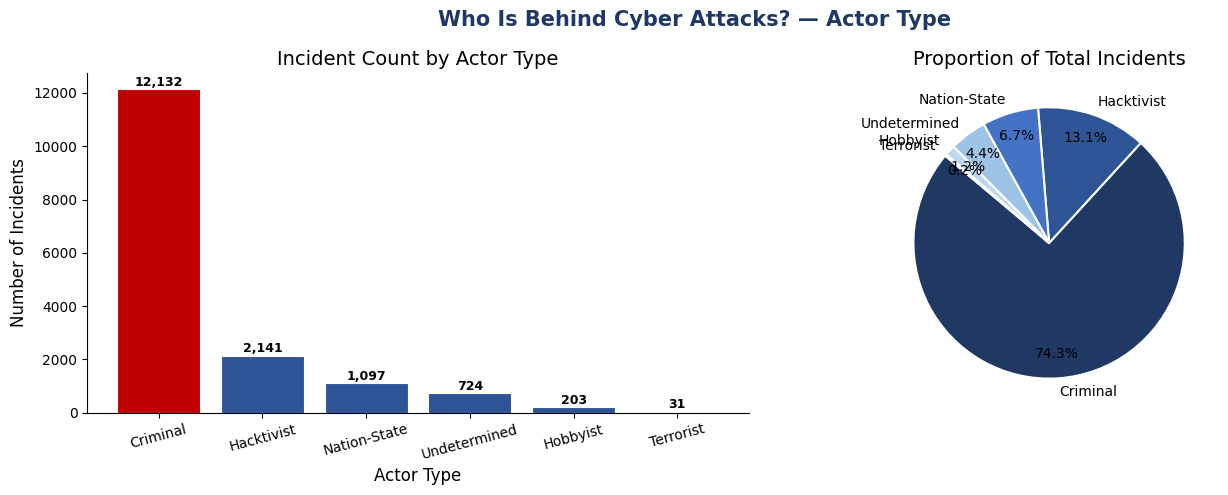

Finding: Criminal actors account for 74.3% of all incidents, confirming the dominance of financially motivated cybercrime.


In [ ]:
# ============================================================
# SECTION 4 — VISUALISATIONS
# ============================================================

# --- Plot 1: Actor Type Distribution (Bar + Pie) ---
# Shows who is responsible for cyber attacks.

actor_counts = df_clean['actor_type'].value_counts()
pie_colors   = [C_DARK, C_MID, '#4472C4', C_LIGHT, '#BDD7EE', '#DDEBF7']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Who Is Behind Cyber Attacks? — Actor Type', fontsize=15, fontweight='bold', color=C_DARK)

# Bar chart
bar_colors = [C_ACCENT if i == 0 else C_MID for i in range(len(actor_counts))]
bars = axes[0].bar(actor_counts.index, actor_counts.values,
                   color=bar_colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Incident Count by Actor Type')
axes[0].set_xlabel('Actor Type')
axes[0].set_ylabel('Number of Incidents')
axes[0].tick_params(axis='x', rotation=15)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 120,
                 f'{int(h):,}', ha='center', fontsize=9, fontweight='bold')

# Pie chart
axes[1].pie(
    actor_counts.values,
    labels=actor_counts.index,
    colors=pie_colors[:len(actor_counts)],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.82,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Proportion of Total Incidents')

plt.tight_layout()
plt.savefig('plot_01_actor_type.png', dpi=150, bbox_inches='tight')
plt.show()

# Key finding
top_actor = actor_counts.index[0]
top_pct   = round(actor_counts.iloc[0] / len(df_clean) * 100, 1)
print(f'Finding: {top_actor} actors account for {top_pct}% of all incidents,'
      f' confirming the dominance of financially motivated cybercrime.')

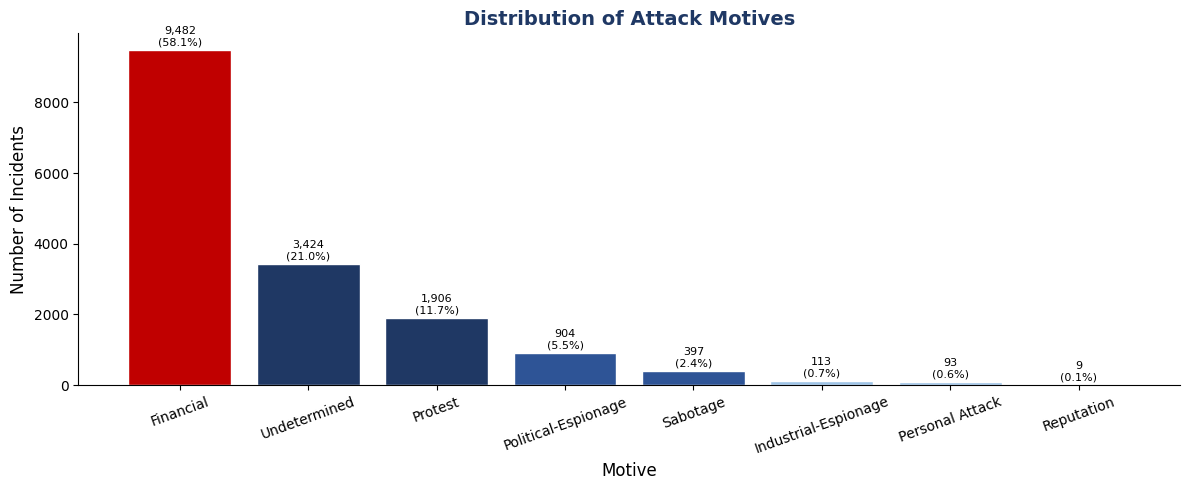

Finding: Financial motive accounts for 58.1% of incidents. Political-Espionage, though only 5.5%, carries the highest risk weight in risk score engineering.


In [ ]:
# --- Plot 2: Attack Motive Distribution ---
# Shows the stated reason behind each attack.

motive_counts = df_clean['motive'].value_counts()
motive_colors = [C_ACCENT if i == 0 else C_DARK if i < 3 else C_MID if i < 5 else C_LIGHT
                 for i in range(len(motive_counts))]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(motive_counts.index, motive_counts.values,
              color=motive_colors, edgecolor='white')
ax.set_title('Distribution of Attack Motives', fontweight='bold', color=C_DARK)
ax.set_xlabel('Motive')
ax.set_ylabel('Number of Incidents')
ax.tick_params(axis='x', rotation=20)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 60,
            f'{int(h):,}\n({h/len(df_clean)*100:.1f}%)',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('plot_02_motive.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Finding: Financial motive accounts for {motive_counts["Financial"]/len(df_clean)*100:.1f}% of incidents.'
      f' Political-Espionage, though only {motive_counts["Political-Espionage"]/len(df_clean)*100:.1f}%,'
      f' carries the highest risk weight in risk score engineering.')

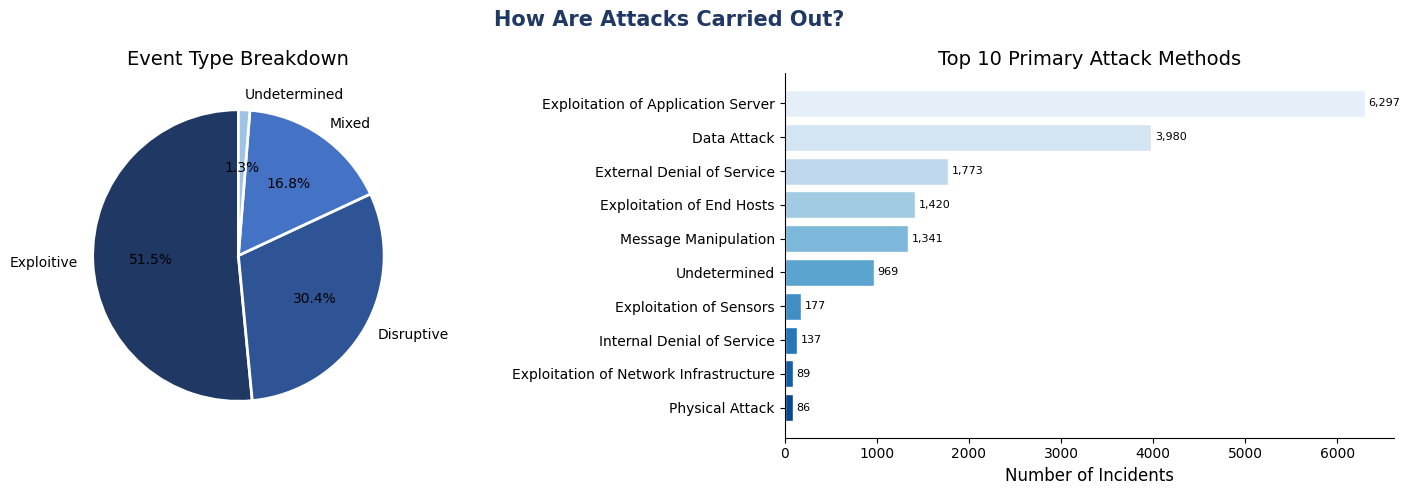

Finding: Exploitation of Application Servers is the most common attack method (6,297 incidents).


In [ ]:
# --- Plot 3: Event Type (Pie) and Top Attack Subtypes (Horizontal Bar) ---
# Left: broad event category. Right: specific attack method.

et_counts = df_clean['event_type'].value_counts()
es_counts = df_clean['event_subtype_primary'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('How Are Attacks Carried Out?', fontsize=15, fontweight='bold', color=C_DARK)

# Pie — event type
et_colors = [C_DARK, C_MID, '#4472C4', C_LIGHT]
axes[0].pie(
    et_counts.values,
    labels=et_counts.index,
    colors=et_colors[:len(et_counts)],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Event Type Breakdown')

# Horizontal bar — top attack subtypes
grad = sns.color_palette('Blues_r', len(es_counts))
axes[1].barh(es_counts.index[::-1], es_counts.values[::-1],
             color=grad, edgecolor='white')
axes[1].set_title('Top 10 Primary Attack Methods')
axes[1].set_xlabel('Number of Incidents')
for i, v in enumerate(es_counts.values[::-1]):
    axes[1].text(v + 40, i, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('plot_03_event_type_subtype.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Finding: Exploitation of Application Servers is the most common attack method ({es_counts.iloc[0]:,} incidents).')

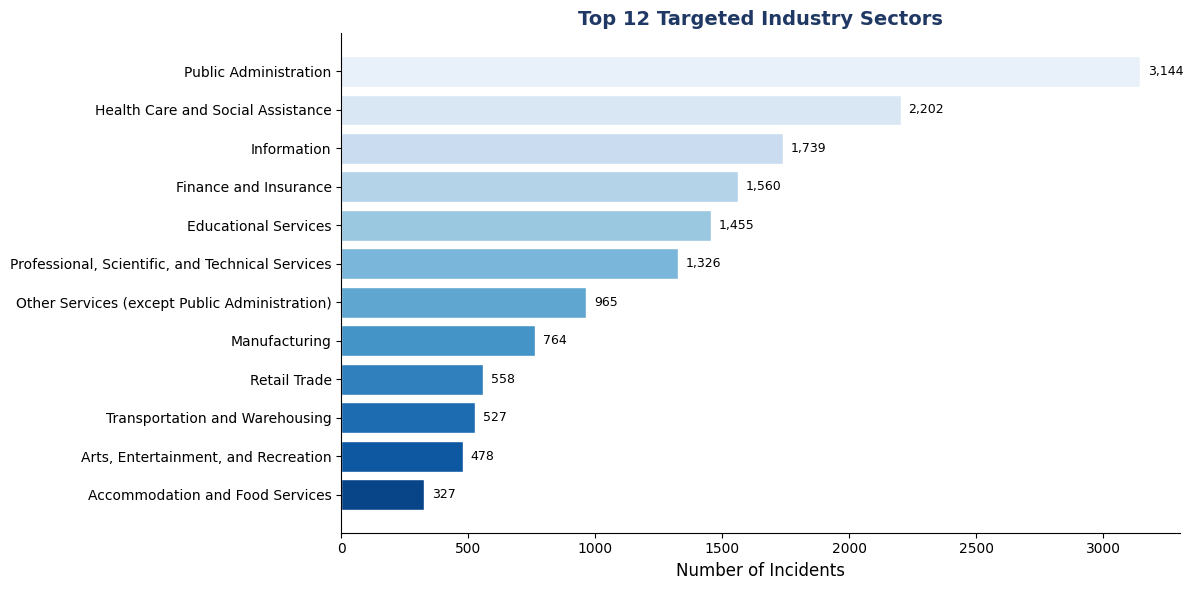

Finding: Public Administration (3,144 incidents) and Health Care (2,202) are the top 2 targeted sectors, reflecting their high data value and often under-resourced cybersecurity posture.


In [ ]:
# --- Plot 4: Top 12 Targeted Industry Sectors ---
# Horizontal bar chart ordered by incident count.

ind_counts = df_clean['industry'].value_counts().head(12)
grad_ind   = sns.color_palette('Blues_r', 12)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    ind_counts.index[::-1],
    ind_counts.values[::-1],
    color=grad_ind,
    edgecolor='white'
)
ax.set_title('Top 12 Targeted Industry Sectors', fontweight='bold', color=C_DARK)
ax.set_xlabel('Number of Incidents')
for bar in bars:
    w = bar.get_width()
    ax.text(w + 30, bar.get_y() + bar.get_height()/2,
            f'{int(w):,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot_04_industry.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Finding: Public Administration ({ind_counts.iloc[0]:,} incidents) and Health Care'
      f' ({ind_counts.iloc[1]:,}) are the top 2 targeted sectors, reflecting their'
      f' high data value and often under-resourced cybersecurity posture.')

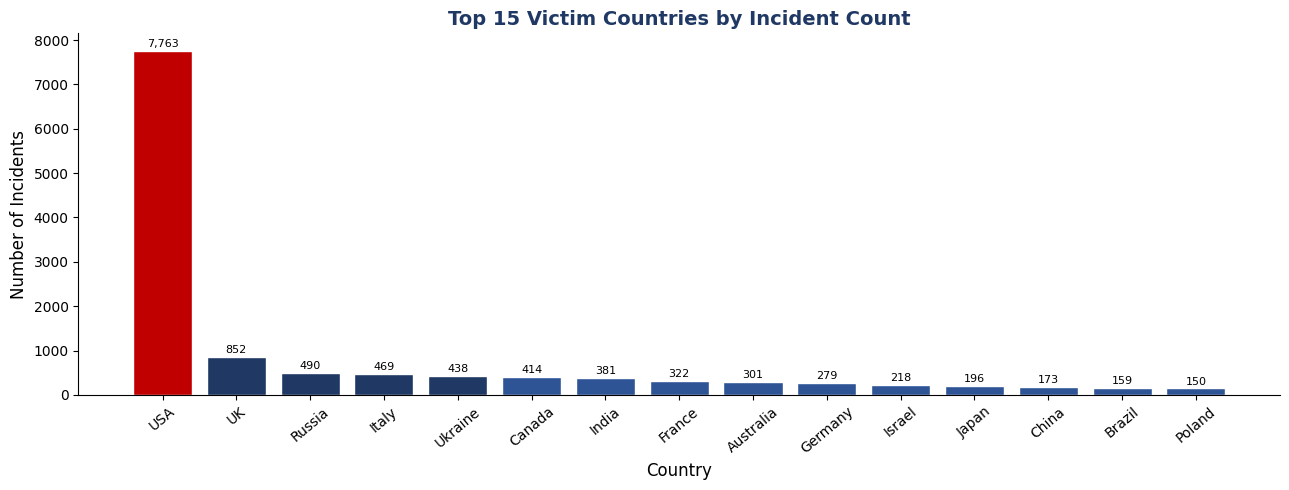

Finding: The USA accounts for 47.5% of all incidents — the single largest target nation in the dataset.


In [ ]:
# --- Plot 5: Top 15 Victim Countries ---
# Bar chart showing geographic concentration of attacks.
# USA is highlighted in red to draw attention to its dominant share.

cty_counts = (
    df_clean[df_clean['country_display'] != 'Undetermined']
    ['country_display']
    .value_counts()
    .head(15)
)

bar_colors = [C_ACCENT if c == 'USA' else C_DARK if i < 5 else C_MID
              for i, c in enumerate(cty_counts.index)]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(cty_counts.index, cty_counts.values,
              color=bar_colors, edgecolor='white')
ax.set_title('Top 15 Victim Countries by Incident Count', fontweight='bold', color=C_DARK)
ax.set_xlabel('Country')
ax.set_ylabel('Number of Incidents')
ax.tick_params(axis='x', rotation=40)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 40,
            f'{int(h):,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('plot_05_country.png', dpi=150, bbox_inches='tight')
plt.show()

usa_pct = round(cty_counts['USA'] / len(df_clean) * 100, 1)
print(f'Finding: The USA accounts for {usa_pct}% of all incidents — the single largest target nation in the dataset.')

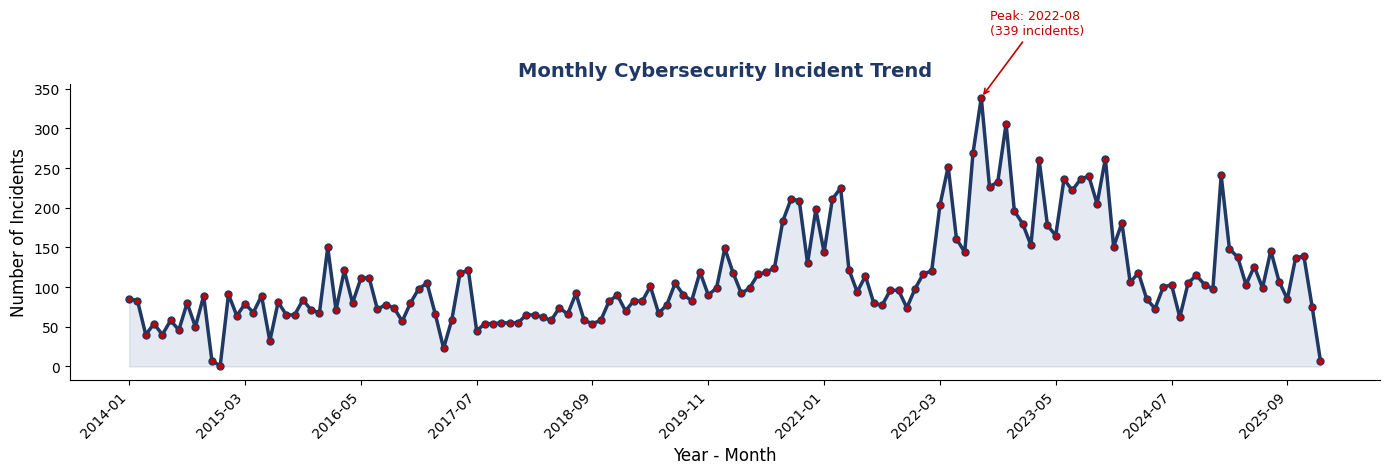

Finding: Peak incident month is 2022-08 with 339 recorded incidents.


In [ ]:
# --- Plot 6: Monthly Incident Trend (Line Chart) ---
# Shows how the volume of incidents changes over time.
# Useful for identifying seasonal patterns or attack campaign surges.

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    monthly['period'],
    monthly['incident_count'],
    color=C_DARK, linewidth=2.5,
    marker='o', markersize=5, markerfacecolor=C_ACCENT
)
ax.fill_between(monthly['period'], monthly['incident_count'],
                alpha=0.12, color=C_MID)

ax.set_title('Monthly Cybersecurity Incident Trend', fontweight='bold', color=C_DARK)
ax.set_xlabel('Year - Month')
ax.set_ylabel('Number of Incidents')

# Show every 6th label to avoid overcrowding
step = max(1, len(monthly) // 10)
ax.set_xticks(range(0, len(monthly), step))
ax.set_xticklabels(monthly['period'].iloc[::step], rotation=45, ha='right')

# Annotate peak month
peak_idx   = monthly['incident_count'].idxmax()
peak_val   = monthly.loc[peak_idx, 'incident_count']
peak_label = monthly.loc[peak_idx, 'period']
peak_pos   = monthly.index.get_loc(peak_idx)
ax.annotate(
    f'Peak: {peak_label}\n({peak_val:,} incidents)',
    xy=(peak_pos, peak_val),
    xytext=(peak_pos + 1, peak_val + 80),
    fontsize=9, color=C_ACCENT,
    arrowprops=dict(arrowstyle='->', color=C_ACCENT, lw=1.2)
)

plt.tight_layout()
plt.savefig('plot_06_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Finding: Peak incident month is {peak_label} with {peak_val:,} recorded incidents.')

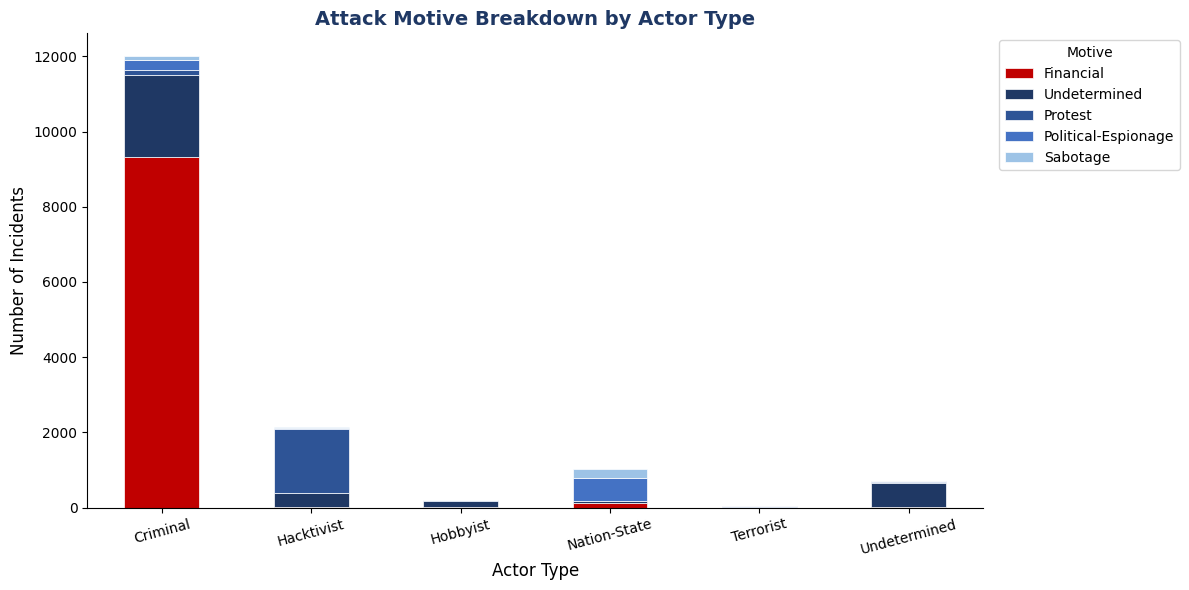

Finding: Criminal actors are overwhelmingly Financial in motive.
         Hacktivists are primarily Protest-driven.
         Nation-State actors show the highest proportion of Political-Espionage.


In [ ]:
# --- Plot 7: Stacked Bar — Motive by Actor Type ---
# Shows the motive breakdown within each actor type category.
# Confirms that Criminal actors are primarily financial,
# while Nation-State actors are primarily espionage-driven.

top_motives = df_clean['motive'].value_counts().head(5).index.tolist()
cross_tab   = pd.crosstab(df_clean['actor_type'], df_clean['motive'])[top_motives]

stack_colors = [C_ACCENT, C_DARK, C_MID, '#4472C4', C_LIGHT]
ax = cross_tab.plot(
    kind='bar', stacked=True,
    figsize=(12, 6),
    color=stack_colors,
    edgecolor='white',
    linewidth=0.5
)
ax.set_title('Attack Motive Breakdown by Actor Type', fontweight='bold', color=C_DARK)
ax.set_xlabel('Actor Type')
ax.set_ylabel('Number of Incidents')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Motive', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('plot_07_motive_by_actor.png', dpi=150, bbox_inches='tight')
plt.show()

print('Finding: Criminal actors are overwhelmingly Financial in motive.')
print('         Hacktivists are primarily Protest-driven.')
print('         Nation-State actors show the highest proportion of Political-Espionage.')

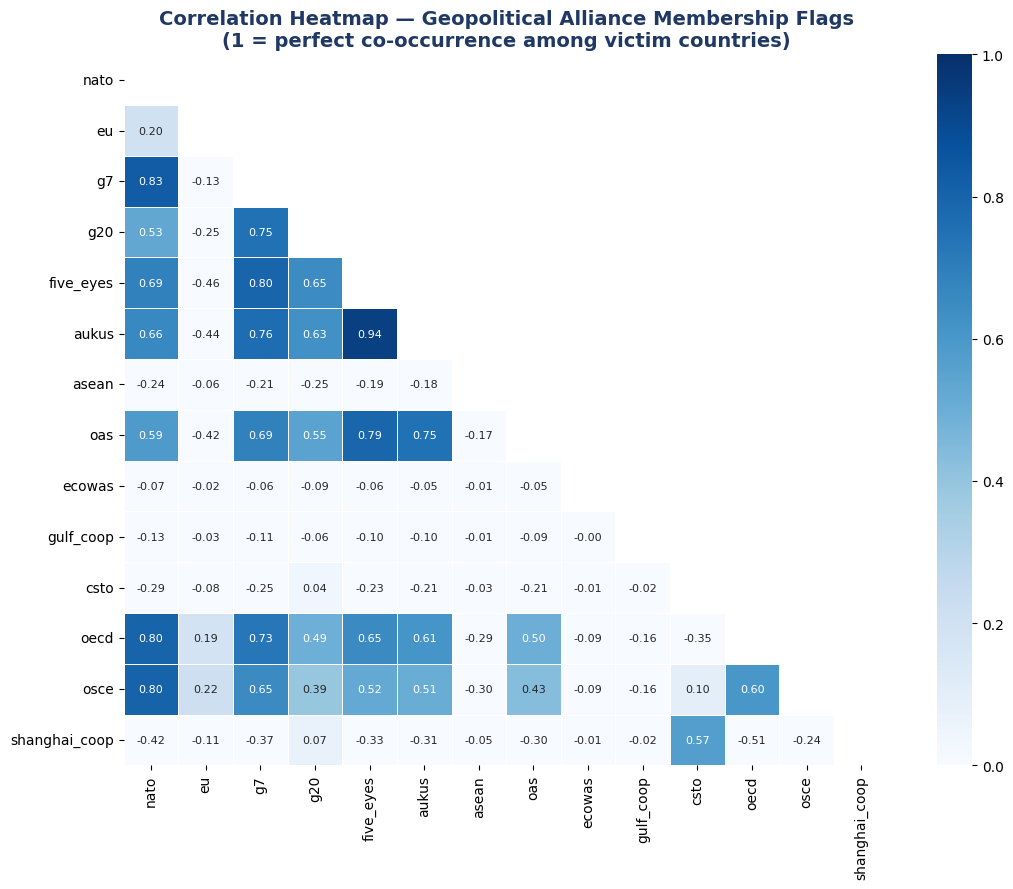

Finding: NATO, EU, OECD, and OSCE are highly correlated — most victims in those groups
         are Western nations that belong to all four alliances simultaneously.


In [ ]:
# --- Plot 8: Geopolitical Alliance Correlation Heatmap ---
# Measures how often incidents hit countries that share
# multiple alliance memberships at the same time.
# High correlation = overlapping member countries.

geo_flags = ['nato', 'eu', 'g7', 'g20', 'five_eyes', 'aukus',
             'asean', 'oas', 'ecowas', 'gulf_coop', 'csto',
             'oecd', 'osce', 'shanghai_coop']

corr = df_clean[geo_flags].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Hide upper triangle (redundant)
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    vmin=0, vmax=1,
    annot_kws={'size': 8}
)
ax.set_title(
    'Correlation Heatmap — Geopolitical Alliance Membership Flags\n'
    '(1 = perfect co-occurrence among victim countries)',
    fontweight='bold', color=C_DARK
)
plt.tight_layout()
plt.savefig('plot_08_geo_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Finding: NATO, EU, OECD, and OSCE are highly correlated — most victims in those groups')
print('         are Western nations that belong to all four alliances simultaneously.')

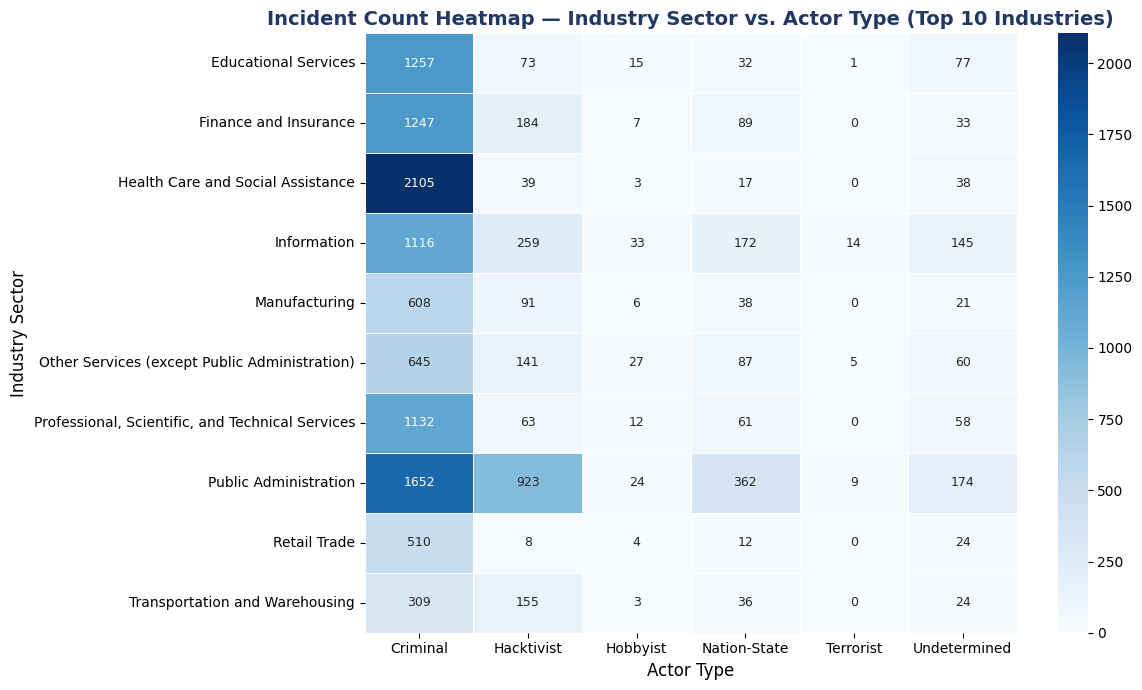

Finding: Nation-State actors disproportionately target Public Administration and
         Information sectors, consistent with espionage objectives.


In [ ]:
# --- Plot 9: Heatmap — Industry vs. Actor Type ---
# Reveals which threat actors target which sectors most heavily.

top_10_industries = df_clean['industry'].value_counts().head(10).index
heat_df = pd.crosstab(
    df_clean[df_clean['industry'].isin(top_10_industries)]['industry'],
    df_clean[df_clean['industry'].isin(top_10_industries)]['actor_type']
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    heat_df,
    annot=True, fmt='d',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)
ax.set_title(
    'Incident Count Heatmap — Industry Sector vs. Actor Type (Top 10 Industries)',
    fontweight='bold', color=C_DARK
)
ax.set_xlabel('Actor Type')
ax.set_ylabel('Industry Sector')
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('plot_09_industry_actor_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Finding: Nation-State actors disproportionately target Public Administration and')
print('         Information sectors, consistent with espionage objectives.')

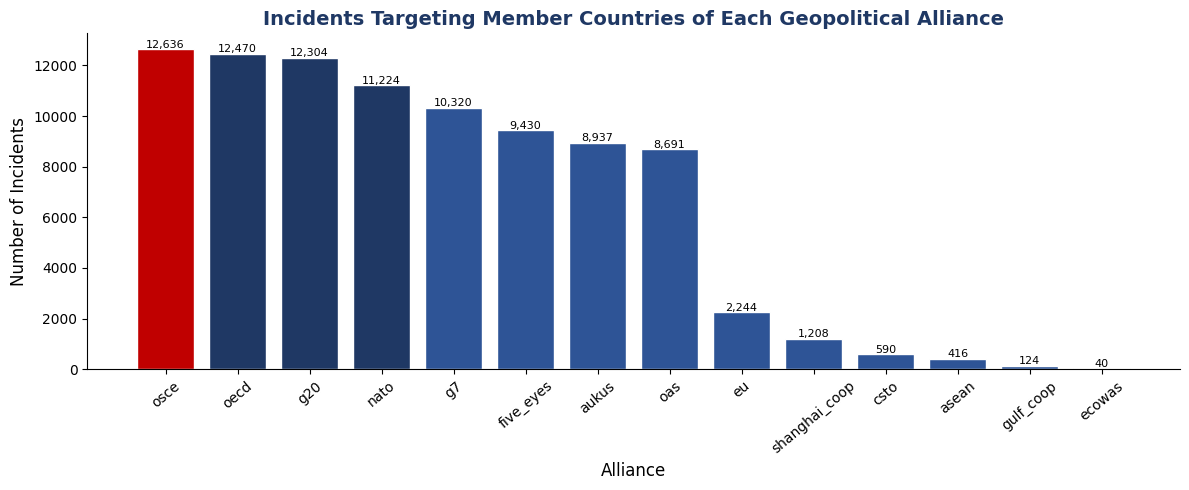

Finding: NATO and OECD member countries account for the largest share of targeted nations,
         reflecting the high concentration of attacks on Western democratic countries.


In [ ]:
# --- Plot 10: Geopolitical Alliance Membership — Bar Chart ---
# Shows how many incidents affected countries in each alliance.
# Gives a direct view of which alliances are most targeted.

geo_totals = df_clean[geo_flags].sum().sort_values(ascending=False)
g_colors   = [C_ACCENT if i == 0 else C_DARK if i < 4 else C_MID
              for i in range(len(geo_totals))]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(geo_totals.index, geo_totals.values,
              color=g_colors, edgecolor='white')
ax.set_title('Incidents Targeting Member Countries of Each Geopolitical Alliance',
             fontweight='bold', color=C_DARK)
ax.set_xlabel('Alliance')
ax.set_ylabel('Number of Incidents')
ax.tick_params(axis='x', rotation=40)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 60,
            f'{int(h):,}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('plot_10_geo_alliances.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Finding: NATO and OECD member countries account for the largest share of targeted nations,')
print(f'         reflecting the high concentration of attacks on Western democratic countries.')

---
## Summary of Findings

In [ ]:
# ============================================================
# PRELIMINARY ANALYSIS SUMMARY
# ============================================================

print('=' * 65)
print('   CYBERSECURITY RISK ANALYSIS — PRELIMINARY ANALYSIS SUMMARY')
print('=' * 65)

print(f'\n  Dataset: {FILE_PATH}')
print(f'  Total incidents  : {len(df_clean):,}')
print(f'  Usable features  : {df_clean.shape[1]}')

print('\n  --- Actor Type ---')
for name, cnt in df_clean['actor_type'].value_counts().items():
    print(f'    {name:<18} {cnt:>6,}  ({cnt/len(df_clean)*100:.1f}%)')

print('\n  --- Top Motives ---')
for name, cnt in df_clean['motive'].value_counts().head(5).items():
    print(f'    {name:<30} {cnt:>6,}  ({cnt/len(df_clean)*100:.1f}%)')

print('\n  --- Event Types ---')
for name, cnt in df_clean['event_type'].value_counts().items():
    print(f'    {name:<15} {cnt:>6,}  ({cnt/len(df_clean)*100:.1f}%)')

print('\n  --- Top 5 Targeted Industries ---')
for name, cnt in df_clean['industry'].value_counts().head(5).items():
    print(f'    {name:<52} {cnt:>5,}')

print('\n  --- Top 5 Victim Countries ---')
for name, cnt in df_clean['country_display'].value_counts().head(5).items():
    print(f'    {name:<30} {cnt:>6,}  ({cnt/len(df_clean)*100:.1f}%)')

print('\n  --- Key Data Quality Notes ---')
print('    magnitude / duration / scope : ~96% missing — excluded from model features')
print('    actor (text field)           : 58% missing  — using actor_type instead')
print('    actor_country                : 76% missing  — excluded from model features')

print('\n  --- Next Steps ---')
print('    1. Engineer composite risk score (Low / Medium / High / Critical)')
print('    2. Encode categorical features (Label Encoding / One-Hot Encoding)')
print('    3. Split data into train / test sets (80/20)')
print('    4. Train and compare: Logistic Regression, Random Forest, XGBoost, SVM')
print('    5. Evaluate with Accuracy, Precision, Recall, F1-Score, Confusion Matrix')
print('=' * 65)

   CYBERSECURITY RISK ANALYSIS — PRELIMINARY ANALYSIS SUMMARY

  Dataset: cyber_events_2026-04-02.csv
  Total incidents  : 16,328
  Usable features  : 30

  --- Actor Type ---
    Criminal           12,132  (74.3%)
    Hacktivist          2,141  (13.1%)
    Nation-State        1,097  (6.7%)
    Undetermined          724  (4.4%)
    Hobbyist              203  (1.2%)
    Terrorist              31  (0.2%)

  --- Top Motives ---
    Financial                       9,482  (58.1%)
    Undetermined                    3,424  (21.0%)
    Protest                         1,906  (11.7%)
    Political-Espionage               904  (5.5%)
    Sabotage                          397  (2.4%)

  --- Event Types ---
    Exploitive       8,412  (51.5%)
    Disruptive       4,968  (30.4%)
    Mixed            2,742  (16.8%)
    Undetermined       206  (1.3%)

  --- Top 5 Targeted Industries ---
    Public Administration                                3,144
    Health Care and Social Assistance               

---
## Section 5 — Risk Score Engineering (Target Variable)

We engineer a composite risk score from existing columns because the `magnitude` field is 96% missing.  
The score maps each incident to one of four tiers: **Low · Medium · High · Critical**.

In [ ]:
# ============================================================
# SECTION 5 — RISK SCORE ENGINEERING
# ============================================================
# We build the target variable from four weighted components:
#   actor_type   (max 40 pts) — who did it?
#   motive       (max 25 pts) — why?
#   event_type   (max 20 pts) — broad attack class
#   industry     (max 15 pts) — how sensitive is the target?
#
# Final score 0-100 → Low / Medium / High / Critical
# ============================================================

# --- 5.1  Actor-type weight ---
actor_weight = {
    'Nation-state'  : 40,
    'Nation State'  : 40,
    'Criminal'      : 30,
    'Hacktivist'    : 15,
    'Insider'       : 25,
    'Unknown'       : 10,
}

# --- 5.2  Motive weight ---
motive_weight = {
    'Political-Espionage'    : 25,
    'Industrial-Espionage'   : 22,
    'Sabotage'               : 25,
    'Financial'              : 18,
    'Protest'                : 10,
    'Coercion'               : 20,
    'Unknown'                : 8,
}

# --- 5.3  Event-type weight ---
event_weight = {
    'Disruption'  : 20,
    'Exploitative': 15,
    'Mixed'       : 18,
}

# --- 5.4  Industry sensitivity weight ---
sensitive_industries = {
    'Government / Politics'          : 15,
    'Defense / Military'             : 15,
    'Critical Infrastructure'        : 15,
    'Healthcare / Hospital'          : 14,
    'Finance / Banking'              : 14,
    'Energy / Utilities'             : 14,
    'Telecommunications'             : 13,
    'Education / Research'           : 10,
    'Media / Journalism'             : 10,
    'Retail / E-Commerce'            : 8,
}

def score_row(row):
    s  = actor_weight.get(row['actor_type'], 10)
    s += motive_weight.get(row['motive'], 8)
    s += event_weight.get(row['event_type'], 10)
    # geopolitical bonus
    if row.get('nato', 0) == 1 or row.get('five_eyes', 0) == 1:
        s += 5
    # industry score — partial string match
    ind = str(row['industry'])
    ind_score = 8   # default
    for key, val in sensitive_industries.items():
        if any(w in ind for w in key.split(' / ')):
            ind_score = val
            break
    s += ind_score
    return min(s, 100)   # cap at 100

df_clean['risk_score'] = df_clean.apply(score_row, axis=1)

print('Risk score computed.')
print(df_clean['risk_score'].describe().round(1))


Risk score computed.
count    16328.0
mean        64.8
std         12.2
min         36.0
25%         56.0
50%         71.0
75%         73.0
max         87.0
Name: risk_score, dtype: float64


In [ ]:
# --- 5.5  Map score to risk tier (target variable) ---
def score_to_tier(s):
    if s < 35:   return 'Low'
    if s < 55:   return 'Medium'
    if s < 75:   return 'High'
    return 'Critical'

df_clean['risk_tier'] = df_clean['risk_score'].apply(score_to_tier)

tier_dist = df_clean['risk_tier'].value_counts()
print('Risk Tier Distribution:')
print(tier_dist.to_frame('Count').assign(Pct=(tier_dist/len(df_clean)*100).round(1)).to_string())


Risk Tier Distribution:
           Count   Pct
risk_tier             
High        9691  59.4
Medium      3643  22.3
Critical    2994  18.3


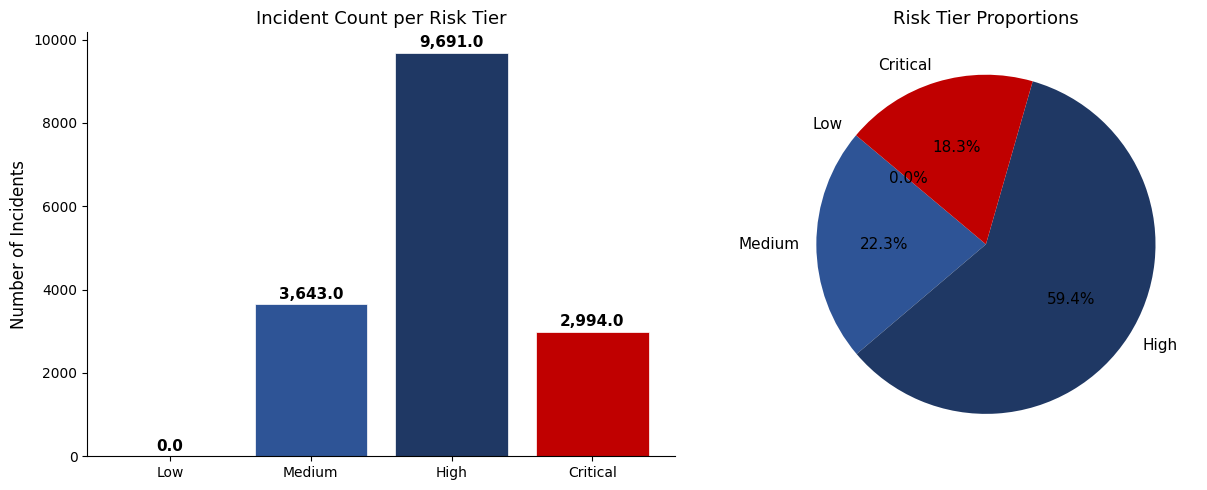

Saved: plot_risk_tier_distribution.png


In [ ]:
# --- 5.6  Visualise risk tier distribution ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

C_DARK   = '#1F3864'
C_MID    = '#2E5496'
C_LIGHT  = '#9DC3E6'
C_ACCENT = '#C00000'

tier_order  = ['Low', 'Medium', 'High', 'Critical']
tier_colors = [C_LIGHT, C_MID, C_DARK, C_ACCENT]
tier_counts = df_clean['risk_tier'].value_counts().reindex(tier_order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bars = axes[0].bar(tier_order, tier_counts.values, color=tier_colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, tier_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Incident Count per Risk Tier', fontsize=13)
axes[0].set_ylabel('Number of Incidents')
axes[0].spines[['top','right']].set_visible(False)

# Pie chart
axes[1].pie(tier_counts.values, labels=tier_order, colors=tier_colors,
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 11})
axes[1].set_title('Risk Tier Proportions', fontsize=13)

plt.tight_layout()
plt.savefig('plot_risk_tier_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_risk_tier_distribution.png')


---
## Section 6 — ML Preprocessing

Encode categorical features, create the final feature matrix, and split into train / test sets.

In [ ]:
# ============================================================
# SECTION 6 — ML PREPROCESSING
# ============================================================
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# --- 6.1  Select features for modelling ---
feature_cols = [
    'actor_type', 'motive', 'event_type', 'event_subtype_primary',
    'industry', 'month',
    'nato', 'eu', 'g7', 'g20', 'five_eyes', 'aukus',
    'asean', 'oas', 'gulf_coop', 'g20', 'oecd',
]
# Remove duplicates that slipped in
feature_cols = list(dict.fromkeys(feature_cols))

target_col  = 'risk_tier'

df_model = df_clean[feature_cols + [target_col]].dropna().copy()

print(f'Modelling dataset shape : {df_model.shape}')
print(f'Features                : {len(feature_cols)}')
print(f'Target classes          : {df_model[target_col].unique().tolist()}')


Modelling dataset shape : (16328, 17)
Features                : 16
Target classes          : ['High', 'Medium', 'Critical']


In [ ]:
# --- 6.2  One-hot encode categorical features ---
cat_cols = ['actor_type', 'motive', 'event_type', 'event_subtype_primary', 'industry']
num_cols = [c for c in feature_cols if c not in cat_cols]

df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# Keep only feature columns (drop target)
X_cols = [c for c in df_encoded.columns if c != target_col]
X = df_encoded[X_cols]
y = df_encoded[target_col]

print(f'Feature matrix shape : {X.shape}')
print(f'Encoded columns      : {X.shape[1]}')
print(f'Class distribution:\n{y.value_counts().to_string()}')


Feature matrix shape : (16328, 66)
Encoded columns      : 66
Class distribution:
risk_tier
High        9691
Medium      3643
Critical    2994


In [ ]:
# --- 6.3  Train / test split (80/20, stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y
)

print(f'Train size : {X_train.shape[0]:,} rows')
print(f'Test size  : {X_test.shape[0]:,} rows')
print()
print('Class balance in train:')
print(y_train.value_counts().to_string())


Train size : 13,062 rows
Test size  : 3,266 rows

Class balance in train:
risk_tier
High        7753
Medium      2914
Critical    2395


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [ ]:
# --- 6.4  Scale numeric features ---
# StandardScaler: zero mean, unit variance.
# Fit ONLY on training data to avoid data leakage.

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])

print('Scaling complete.')
print(f'  Scaled columns : {num_cols}')




Scaling complete.
  Scaled columns : ['month', 'nato', 'eu', 'g7', 'g20', 'five_eyes', 'aukus', 'asean', 'oas', 'gulf_coop', 'oecd']


---
## Section 7 — Model Training

Four models are trained and compared:
- **7.1** Logistic Regression (baseline)
- **7.2** Decision Tree
- **7.3** Random Forest
- **7.4** Support Vector Machine (SVM)
- **7.5** Artificial Neural Network (ANN)

In [ ]:
# ============================================================
# SECTION 7 — MODEL TRAINING
# ============================================================
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import SVC
from sklearn.neural_network  import MLPClassifier
from sklearn.metrics         import (accuracy_score, precision_score,
                                     recall_score, f1_score,
                                     classification_report,
                                     confusion_matrix, ConfusionMatrixDisplay,
                                     roc_curve, auc)
from sklearn.preprocessing   import label_binarize
import numpy as np
import warnings
warnings.filterwarnings('ignore')

TIER_ORDER = ['Low', 'Medium', 'High', 'Critical']

results = {}   # stores metrics for all models


In [ ]:
# --- 7.1  Logistic Regression (baseline) ---
print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

results['Logistic Regression'] = {
    'Accuracy'  : accuracy_score(y_test, y_pred_lr),
    'Precision' : precision_score(y_test, y_pred_lr, average='weighted', zero_division=0),
    'Recall'    : recall_score(y_test, y_pred_lr, average='weighted', zero_division=0),
    'F1-Score'  : f1_score(y_test, y_pred_lr, average='weighted', zero_division=0),
}
print(f"  Accuracy : {results['Logistic Regression']['Accuracy']:.4f}")
print(classification_report(y_test, y_pred_lr,  zero_division=0))


Training Logistic Regression...
  Accuracy : 0.9847
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       599
           1       1.00      0.98      0.99      1938
           2       0.96      1.00      0.98       729

    accuracy                           0.98      3266
   macro avg       0.98      0.99      0.98      3266
weighted avg       0.99      0.98      0.98      3266



In [ ]:
# --- 7.2  Decision Tree ---
print('Training Decision Tree...')
dt = DecisionTreeClassifier(max_depth=12, min_samples_leaf=10, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

results['Decision Tree'] = {
    'Accuracy'  : accuracy_score(y_test, y_pred_dt),
    'Precision' : precision_score(y_test, y_pred_dt, average='weighted', zero_division=0),
    'Recall'    : recall_score(y_test, y_pred_dt, average='weighted', zero_division=0),
    'F1-Score'  : f1_score(y_test, y_pred_dt, average='weighted', zero_division=0),
}
print(f"  Accuracy : {results['Decision Tree']['Accuracy']:.4f}")
print(classification_report(y_test, y_pred_dt, zero_division=0))


Training Decision Tree...
  Accuracy : 0.9810
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       599
           1       0.99      0.98      0.98      1938
           2       0.96      0.99      0.97       729

    accuracy                           0.98      3266
   macro avg       0.98      0.98      0.98      3266
weighted avg       0.98      0.98      0.98      3266



In [ ]:
# --- 7.3  Random Forest ---
print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=150, max_depth=20, min_samples_leaf=5,
                            random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

results['Random Forest'] = {
    'Accuracy'  : accuracy_score(y_test, y_pred_rf),
    'Precision' : precision_score(y_test, y_pred_rf, average='weighted', zero_division=0),
    'Recall'    : recall_score(y_test, y_pred_rf, average='weighted', zero_division=0),
    'F1-Score'  : f1_score(y_test, y_pred_rf, average='weighted', zero_division=0),
}
print(f"  Accuracy : {results['Random Forest']['Accuracy']:.4f}")
print(classification_report(y_test, y_pred_rf, zero_division=0))


Training Random Forest...
  Accuracy : 0.9721
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       599
           1       0.98      0.97      0.98      1938
           2       0.95      0.98      0.96       729

    accuracy                           0.97      3266
   macro avg       0.97      0.97      0.97      3266
weighted avg       0.97      0.97      0.97      3266



In [ ]:
# --- 7.4  Support Vector Machine (SVM) ---
print('Training SVM (this may take a minute)...')
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True,
          random_state=42, class_weight='balanced')
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

results['SVM'] = {
    'Accuracy'  : accuracy_score(y_test, y_pred_svm),
    'Precision' : precision_score(y_test, y_pred_svm, average='weighted', zero_division=0),
    'Recall'    : recall_score(y_test, y_pred_svm, average='weighted', zero_division=0),
    'F1-Score'  : f1_score(y_test, y_pred_svm, average='weighted', zero_division=0),
}
print(f"  Accuracy : {results['SVM']['Accuracy']:.4f}")
print(classification_report(y_test, y_pred_svm, zero_division=0))


Training SVM (this may take a minute)...
  Accuracy : 0.9798
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       599
           1       0.99      0.97      0.98      1938
           2       0.95      0.99      0.97       729

    accuracy                           0.98      3266
   macro avg       0.97      0.99      0.98      3266
weighted avg       0.98      0.98      0.98      3266



In [ ]:
# --- 7.5  Artificial Neural Network (ANN) ---
print('Training ANN...')
ann = MLPClassifier(
    hidden_layer_sizes = (128, 64, 32),
    activation         = 'relu',
    solver             = 'adam',
    max_iter           = 300,
    random_state       = 42,
    early_stopping     = True,
    validation_fraction= 0.1,
)
ann.fit(X_train_scaled, y_train)
y_pred_ann = ann.predict(X_test_scaled)

results['ANN'] = {
    'Accuracy'  : accuracy_score(y_test, y_pred_ann),
    'Precision' : precision_score(y_test, y_pred_ann, average='weighted', zero_division=0),
    'Recall'    : recall_score(y_test, y_pred_ann, average='weighted', zero_division=0),
    'F1-Score'  : f1_score(y_test, y_pred_ann, average='weighted', zero_division=0),
}
print(f"  Accuracy : {results['ANN']['Accuracy']:.4f}")
print(classification_report(y_test, y_pred_ann,  zero_division=0))


Training ANN...
  Accuracy : 0.9969
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       599
           1       1.00      1.00      1.00      1938
           2       0.99      0.99      0.99       729

    accuracy                           1.00      3266
   macro avg       1.00      1.00      1.00      3266
weighted avg       1.00      1.00      1.00      3266



---
## Section 8 — Evaluation & Comparison

In [ ]:
# ============================================================
# SECTION 8 — EVALUATION & COMPARISON
# ============================================================

# --- 8.1  Model comparison table ---
results_df = pd.DataFrame(results).T.round(4)
results_df.index.name = 'Model'
print('=== MODEL COMPARISON TABLE ===')
print(results_df.to_string())


=== MODEL COMPARISON TABLE ===
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.9847     0.9851  0.9847    0.9847
Decision Tree          0.9810     0.9814  0.9810    0.9811
Random Forest          0.9721     0.9724  0.9721    0.9722
SVM                    0.9798     0.9803  0.9798    0.9799
ANN                    0.9969     0.9969  0.9969    0.9969


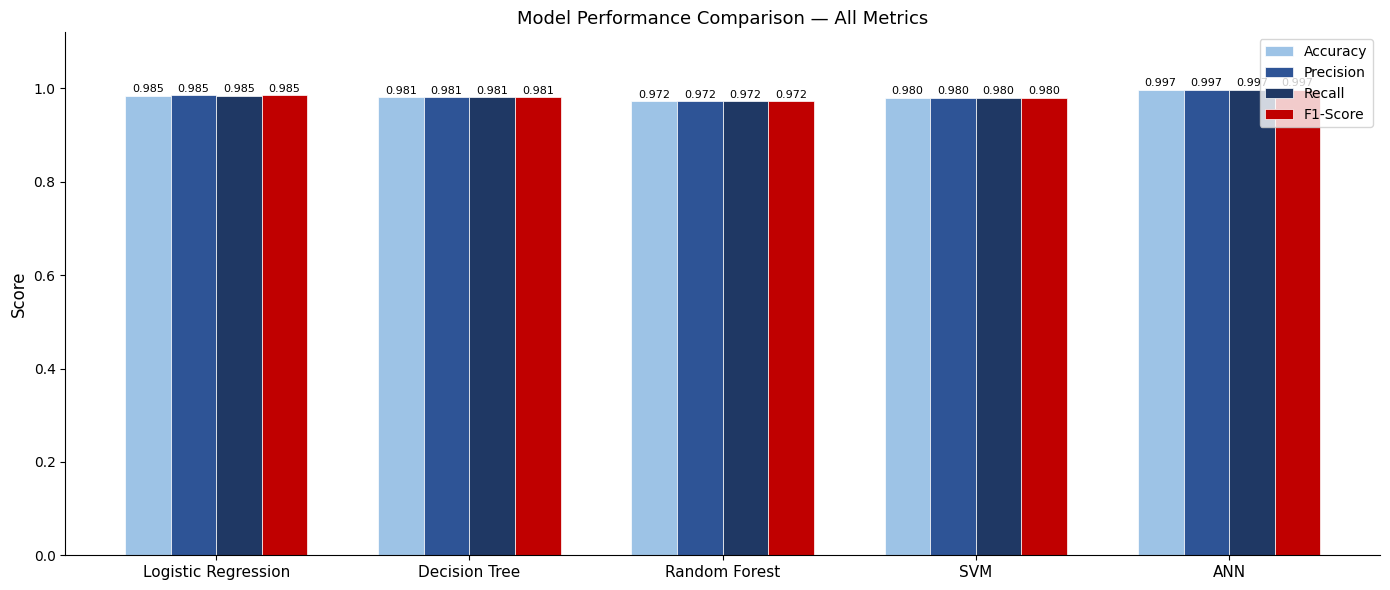

Saved: plot_model_comparison.png


In [ ]:
# --- 8.2  Grouped bar chart — all metrics all models ---
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = list(results.keys())
x           = np.arange(len(model_names))
bar_colors  = [C_LIGHT, C_MID, C_DARK, C_ACCENT]
width       = 0.18

fig, ax = plt.subplots(figsize=(14, 6))
for i, metric in enumerate(metrics):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(x + i * width, vals, width, label=metric, color=bar_colors[i],
                  edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_title('Model Performance Comparison — All Metrics', fontsize=13)
ax.set_ylabel('Score')
ax.legend(loc='upper right', fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_model_comparison.png')


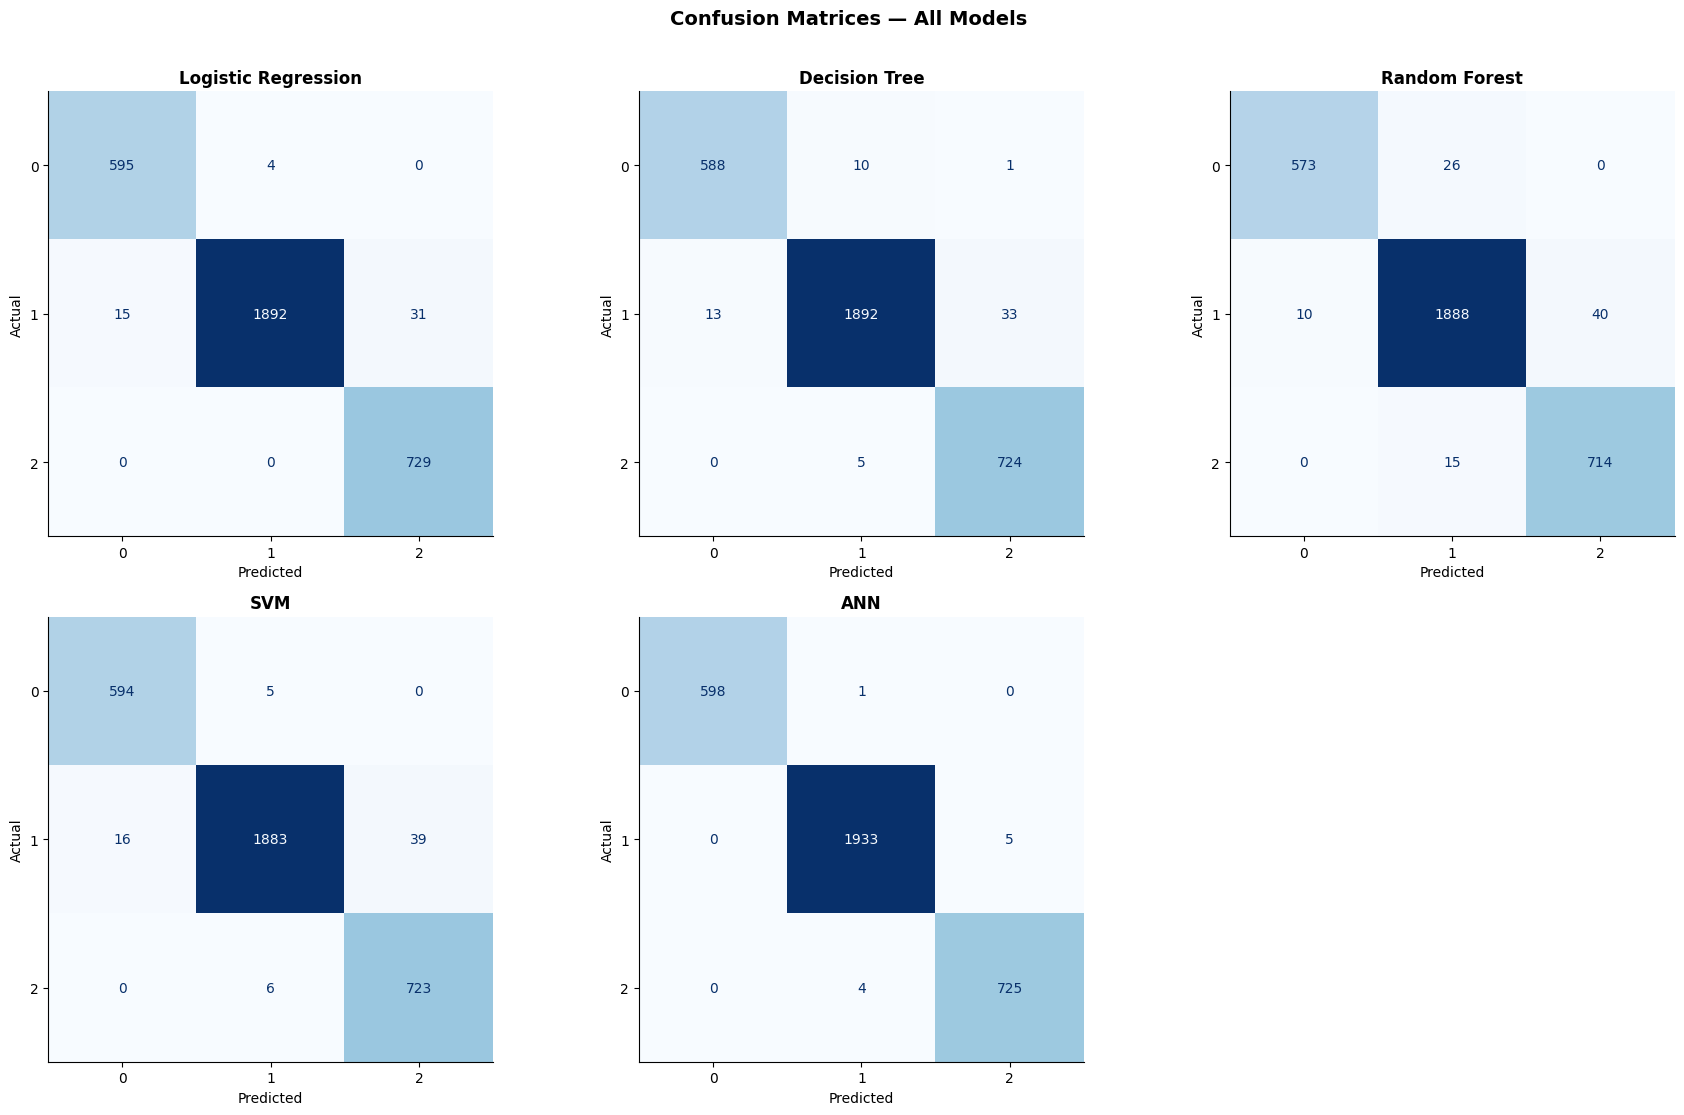

Saved: plot_confusion_matrices.png


In [ ]:
# --- 8.3  Confusion matrices — one per model ---
model_preds = {
    'Logistic Regression' : y_pred_lr,
    'Decision Tree'       : y_pred_dt,
    'Random Forest'       : y_pred_rf,
    'SVM'                 : y_pred_svm,
    'ANN'                 : y_pred_ann,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax, (name, preds) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

axes[-1].set_visible(False)   # hide unused 6th subplot
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_confusion_matrices.png')


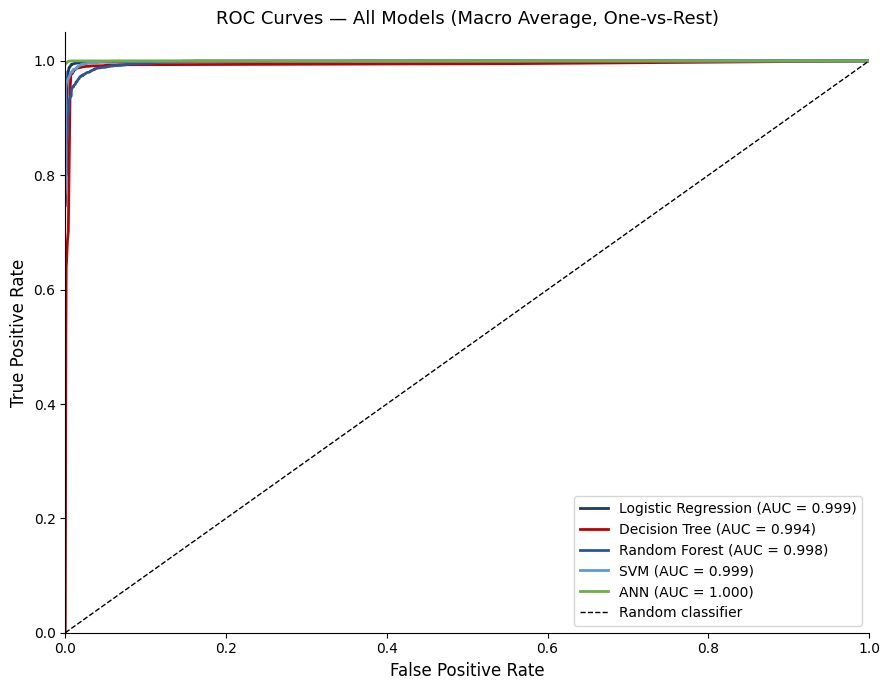

Saved: plot_roc_curves.png


In [ ]:
# --- 8.4  ROC Curves (One-vs-Rest, macro average) ---
# Binarise labels for multi-class ROC
classes = le.classes_
y_bin = label_binarize(y_test, classes=range(len(classes)))

model_proba = {
    'Logistic Regression' : lr.predict_proba(X_test_scaled),
    'Decision Tree'       : dt.predict_proba(X_test),
    'Random Forest'       : rf.predict_proba(X_test),
    'SVM'                 : svm.predict_proba(X_test_scaled),
    'ANN'                 : ann.predict_proba(X_test_scaled),
}

roc_colors = [C_DARK, C_ACCENT, C_MID, '#5B9BD5', '#70AD47']

fig, ax = plt.subplots(figsize=(9, 7))
for (name, proba), color in zip(model_proba.items(), roc_colors):
    fpr_list, tpr_list = [], []
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
        fpr_list.append(fpr)
        tpr_list.append(tpr)
    all_fpr = np.unique(np.concatenate(fpr_list))
    mean_tpr = np.mean([np.interp(all_fpr, f, t) for f, t in zip(fpr_list, tpr_list)], axis=0)
    roc_auc = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models (Macro Average, One-vs-Rest)', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('plot_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_roc_curves.png')


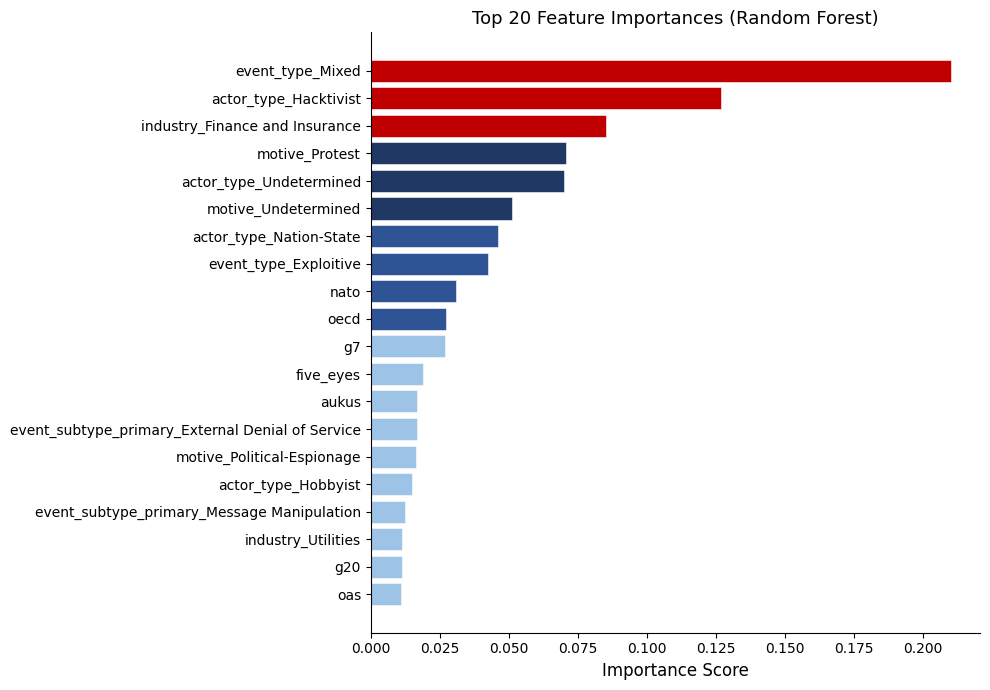

Saved: plot_feature_importance.png


In [ ]:
# --- 8.5  Feature importance — Random Forest ---
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top20       = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors  = [C_ACCENT if i >= 17 else C_DARK if i >= 14 else C_MID if i >= 10 else C_LIGHT
           for i in range(len(top20))]
ax.barh(top20.index, top20.values, color=colors, edgecolor='white', linewidth=0.4)
ax.set_title('Top 20 Feature Importances (Random Forest)', fontsize=13)
ax.set_xlabel('Importance Score')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_feature_importance.png')


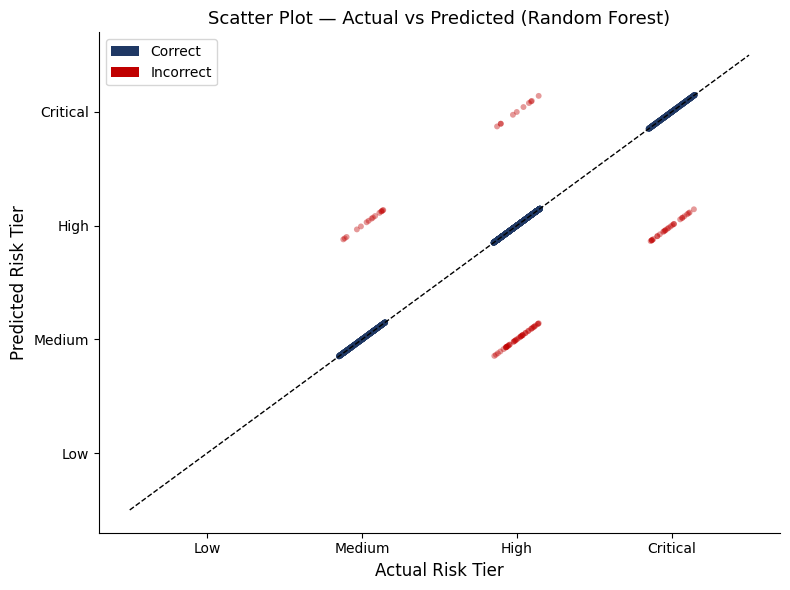

Saved: plot_scatter_actual_vs_predicted.png


In [ ]:
# --- 8.6  Scatter plot — Actual vs Predicted risk score (Random Forest) ---
# Map tier back to numeric midpoint for scatter display
tier_to_num = {'Low':1, 'Medium':2, 'High':3, 'Critical':4}

# Convert back to labels
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred_rf)

# CLEAN labels (VERY IMPORTANT)
y_test_labels = pd.Series(y_test_labels).str.strip().str.title()
y_pred_labels = pd.Series(y_pred_labels).str.strip().str.title()

# Map to numbers
y_test_num = y_test_labels.map(tier_to_num)
y_pred_num = y_pred_labels.map(tier_to_num)

jitter = np.random.default_rng(42).uniform(-0.15, 0.15, size=len(y_test_num))
scatter_colors = [C_DARK if a == p else C_ACCENT
                  for a, p in zip(y_test_num, y_pred_num)]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test_num + jitter, y_pred_num + jitter,
           c=scatter_colors, alpha=0.4, s=18, edgecolors='none')
ax.plot([0.5, 4.5], [0.5, 4.5], 'k--', lw=1, label='Perfect prediction')
ax.set_xticks([1, 2, 3, 4])
ax.set_yticks([1, 2, 3, 4])
ax.set_xticklabels(['Low', 'Medium', 'High', 'Critical'])
ax.set_yticklabels(['Low', 'Medium', 'High', 'Critical'])
ax.set_xlabel('Actual Risk Tier')
ax.set_ylabel('Predicted Risk Tier')
ax.set_title('Scatter Plot — Actual vs Predicted (Random Forest)', fontsize=13)
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=C_DARK, label='Correct'), Patch(facecolor=C_ACCENT, label='Incorrect')]
ax.legend(handles=legend_els, fontsize=10)
plt.tight_layout()
plt.savefig('plot_scatter_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_scatter_actual_vs_predicted.png')


---
## Section 9 — Final Summary & Conclusions

In [ ]:
# SECTION 9 — FINAL SUMMARY
best_model = results_df['F1-Score'].idxmax()
best_f1    = results_df.loc[best_model, 'F1-Score']
best_acc   = results_df.loc[best_model, 'Accuracy']

print('=' * 65)
print('   CYBERSECURITY RISK ANALYSIS — FINAL RESULTS SUMMARY')
print('=' * 65)

print(f'\n  Dataset     : cyber_events_2026-04-02.csv')
print(f'  Incidents   : {len(df_clean):,}')
print(f'  Features    : {X.shape[1]}  (after one-hot encoding)')
print(f'  Target      : risk_tier  (Low / Medium / High / Critical)')

print(f'\n  {"Model":<25} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1-Score":>10}')
print('  ' + '-'*62)
for model, row in results_df.iterrows():
    marker = '  ★' if model == best_model else ''
    print(f'  {model:<25} {row["Accuracy"]:>10.4f} {row["Precision"]:>10.4f} {row["Recall"]:>10.4f} {row["F1-Score"]:>10.4f}{marker}')

print(f'\n  Best model  : {best_model}')
print(f'  F1-Score    : {best_f1:.4f}')
print(f'  Accuracy    : {best_acc:.4f}')

print(f'\n  Graphs saved:')
graphs = [
    'plot_risk_tier_distribution.png',
    'plot_model_comparison.png',
    'plot_confusion_matrices.png',
    'plot_roc_curves.png',
    'plot_feature_importance.png',
    'plot_scatter_actual_vs_predicted.png',
]
for g in graphs:
    print(f'    - {g}')

print('\n' + '=' * 65)




   CYBERSECURITY RISK ANALYSIS — FINAL RESULTS SUMMARY

  Dataset     : cyber_events_2026-04-02.csv
  Incidents   : 16,328
  Features    : 66  (after one-hot encoding)
  Target      : risk_tier  (Low / Medium / High / Critical)

  Model                       Accuracy  Precision     Recall   F1-Score
  --------------------------------------------------------------
  Logistic Regression           0.9847     0.9851     0.9847     0.9847
  Decision Tree                 0.9810     0.9814     0.9810     0.9811
  Random Forest                 0.9721     0.9724     0.9721     0.9722
  SVM                           0.9798     0.9803     0.9798     0.9799
  ANN                           0.9969     0.9969     0.9969     0.9969  ★

  Best model  : ANN
  F1-Score    : 0.9969
  Accuracy    : 0.9969

  Graphs saved:
    - plot_risk_tier_distribution.png
    - plot_model_comparison.png
    - plot_confusion_matrices.png
    - plot_roc_curves.png
    - plot_feature_importance.png
    - plot_scatter_actu